In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import math
import os
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
Capability: (7, 5)


In [3]:
x = torch.randn(1000, 1000).cuda()
y = x @ x
print(y.device)

cuda:0


In [4]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

2.10.0+cu128
12.8
Tesla T4
True


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
print(device)

cuda


In [8]:
class Embbeddings(nn.Module):
    def __init__(self , vocab_size , d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size , d_model)
    def forward(self , x):
        B , T = x.shape
        x_embedded = self.embedding(x)
        return x_embedded

In [9]:
class RMSNorm(nn.Module):
    def __init__(self , d_model , eps = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))
    def forward(self , x):
        # X is now (B , T , C) and we should apply the normalization to each row of X
        rms = torch.sqrt(torch.mean(x**2 , dim = -1 , keepdim = True) + self.eps)
        x = x/rms
        x = self.weight * x
        return x

let's try the complexe one it's more good and understandable

In [10]:
def compute_theta_frequencies(head_dim : int , seq_length : int , theta : float = 10000.0):
    assert head_dim % 2 == 0 , "Head dim should be dividable by 2"
    theta_numerators = torch.arange(0 , head_dim , 2).float()
    theta = 1/(theta)**(theta_numerators/head_dim)
    positions = torch.arange(seq_length)
    freqs = torch.outer(positions , theta)
    freqs_complex = torch.polar(torch.ones_like(freqs) , freqs)
    return freqs_complex

In [11]:
def apply_rotations(x : torch.Tensor ,  head_dim : int , seq_length : int , device : str):
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1] , -1 , 2))
    freqs_complex = compute_theta_frequencies(head_dim, seq_length).to(x.device)  # using x.device is safer than passing device manually
    freqs_complex = freqs_complex.unsqueeze(0).unsqueeze(2)
    
    x_rotated = x_complex*freqs_complex
    x_out = torch.view_as_real(x_rotated)
    x_out = x_out.reshape(*x.shape)
    return x_out

In [12]:
def repeat_kv(x, n_rep):
    B, T, n_kv_heads, head_dim = x.shape  # 👈 extract from tensor directly
    return (
        x[:, :, :, None, :]
        .expand(B, T, n_kv_heads, n_rep, head_dim)
        .reshape(B, T, n_kv_heads * n_rep, head_dim)
    )

In [13]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, max_seq_len=512):
        super().__init__()
        assert n_heads > n_kv_heads
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = d_model // n_heads
        self.group_size = n_heads // n_kv_heads
        self.Wq = nn.Linear(d_model, self.n_heads * self.head_dim, bias=False)
        self.Wk = nn.Linear(d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.Wv = nn.Linear(d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.Wo = nn.Linear(d_model, d_model)
        self.cache_k = torch.zeros(1, self.n_kv_heads, max_seq_len, self.head_dim).to(device)
        self.cache_v = torch.zeros(1, self.n_kv_heads, max_seq_len, self.head_dim).to(device)
        
    def init_cache(self, max_seq_len : int , device ):
        self.cache_k = torch.zeros(1, self.n_kv_heads, max_seq_len, self.head_dim).to(device)
        self.cache_v = torch.zeros(1, self.n_kv_heads, max_seq_len, self.head_dim).to(device)

    def forward(self, x, start_pos=None, use_cache=False):
        B, T, C = x.shape
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        Q = Q.view(B, T, self.n_heads,    self.head_dim)
        K = K.view(B, T, self.n_kv_heads, self.head_dim)
        V = V.view(B, T, self.n_kv_heads, self.head_dim)
    
        Q = apply_rotations(Q, self.head_dim, T, device=device)
        K = apply_rotations(K, self.head_dim, T, device=device)
    

    
        if not use_cache:
            K = repeat_kv(K, self.group_size)
            V = repeat_kv(V, self.group_size)

            Q = Q.transpose(1, 2)
            K = K.transpose(1, 2)
            V = V.transpose(1, 2)
            
            scores = torch.matmul(Q, K.transpose(-2, -1))
            scores = scores / math.sqrt(self.head_dim)          
            mask = torch.tril(torch.ones(T, T, device=x.device))
            scores = scores.masked_fill(~mask.bool(), float("-inf"))  
            scores = F.softmax(scores, dim=-1)
            out = torch.matmul(scores, V)
        else:
            # transpose BEFORE writing to cache
            Q = Q.transpose(1, 2)  # [B, n_heads,    T, head_dim]
            K = K.transpose(1, 2)  # [B, n_kv_heads, T, head_dim]
            V = V.transpose(1, 2)  # [B, n_kv_heads, T, head_dim]
        
            self.cache_k[:, :, start_pos:start_pos+T, :] = K  # 👈 use T not 1
            self.cache_v[:, :, start_pos:start_pos+T, :] = V
        
            K_cached = self.cache_k[:, :, :start_pos+T, :]
            V_cached = self.cache_v[:, :, :start_pos+T, :]
        
            K_cached = repeat_kv(K_cached.transpose(1, 2), self.group_size).transpose(1, 2)
            V_cached = repeat_kv(V_cached.transpose(1, 2), self.group_size).transpose(1, 2)
        
            scores = torch.matmul(Q, K_cached.transpose(-2, -1)) / math.sqrt(self.head_dim)
            weights = F.softmax(scores, dim=-1)
            out = torch.matmul(weights, V_cached)
    
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.Wo(out)

In [14]:
# def forward(self, x, start_pos=None, use_cache=False):
#     B, T, C = x.shape
#     Q = self.Wq(x)
#     K = self.Wk(x)
#     V = self.Wv(x)
#     Q = Q.view(B, T, self.n_heads,    self.head_dim)
#     K = K.view(B, T, self.n_kv_heads, self.head_dim)
#     V = V.view(B, T, self.n_kv_heads, self.head_dim)

#     Q = apply_rotations(Q, self.head_dim, T, device=device)
#     K = apply_rotations(K, self.head_dim, T, device=device)

#     Q = Q.transpose(1, 2)
#     K = K.transpose(1, 2)
#     V = V.transpose(1, 2)

#     if not use_cache:
#         K = repeat_kv(K, self.group_size)
#         V = repeat_kv(V, self.group_size)
#         scores = torch.matmul(Q, K.transpose(-2, -1))
#         scores = scores / math.sqrt(self.head_dim)          
#         mask = torch.tril(torch.ones(T, T, device=x.device))
#         scores = scores.masked_fill(~mask.bool(), float("-inf"))  
#         scores = F.softmax(scores, dim=-1)
#         out = torch.matmul(scores, V)
#     else:
#         self.cache_k[:, :, start_pos:start_pos+1, :] = K
#         self.cache_v[:, :, start_pos:start_pos+1, :] = V
#         K_cached = self.cache_k[:, :, :start_pos+1, :]
#         V_cached = self.cache_v[:, :, :start_pos+1, :]
#         K_cached = repeat_kv(K_cached, self.group_size)     
#         V_cached = repeat_kv(V_cached, self.group_size)     
#         scores = torch.matmul(Q, K_cached.transpose(-2, -1))
#         scores = scores / math.sqrt(self.head_dim)          
#         weights = F.softmax(scores, dim=-1)
#         out = torch.matmul(weights, V_cached)

#     out = out.transpose(1, 2).contiguous().view(B, T, C)
#     return self.Wo(out)

In [15]:
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.SiLU(),
            nn.Linear(4 * d_model, d_model)  # 👈 input must be 4*d_model, not d_model
        )
    def forward(self, x):
        return self.ff(x)

In [16]:
class TransformerBlock(nn.Module):
    def __init__(self , d_model , heads , n_kv_heads):
        super().__init__()
        self.rmsnorm = RMSNorm(d_model)
        self.groupedattention = GroupedQueryAttention(d_model , heads , n_kv_heads)
        self.ff = FeedForward(d_model)
    def forward(self , x , start_pos = None , use_cache = False):
        rms = self.rmsnorm(x)
        grouped_attention = self.groupedattention(rms , start_pos , use_cache)
        residual = x + grouped_attention
        rms2 = self.rmsnorm(residual)
        ff = self.ff(rms2)
        residual2 = residual + ff
        return residual2

In [17]:
class Llama(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_kv_heads, n_layers=6):
        super().__init__()
        self.embeddings = Embbeddings(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, n_heads, n_kv_heads) for _ in range(n_layers)
        ])
        self.rmsnorm = RMSNorm(d_model)
        self.wout = nn.Linear(d_model, vocab_size)

    def forward(self, x, start_pos=0, use_cache=False):  # 👈 add these
        x = x.to(device)
        x = self.embeddings(x)
        for layer in self.layers:
            x = layer(x, start_pos=start_pos, use_cache=use_cache)  # 👈 pass through
        x = self.rmsnorm(x)
        return self.wout(x)

In [18]:
768 / 64

12.0

In [19]:
vocab_size = 50257
d_model = 768
n_heads = 12
n_kv_heads = 4

In [20]:
model = Llama(vocab_size , d_model , n_heads , n_kv_heads)
model = model.to(device)

In [21]:
x = torch.tensor([[1,5,7,8,9,6,5,4]])
print(x)

tensor([[1, 5, 7, 8, 9, 6, 5, 4]])


In [22]:
x.shape

torch.Size([1, 8])

In [23]:
out = model(x , start_pos = None, use_cache = False)

In [24]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
tokenized_text = tokenizer.encode("Hello my name is Reda")
tokenized_text

[15496, 616, 1438, 318, 2297, 64]

In [26]:
df = pd.read_csv("/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/train.csv")
df[:10]

,text
0,"One day, a little girl named Lily found a need..."
1,"Once upon a time, there was a little car named..."
2,"One day, a little fish named Fin was swimming ..."
3,"Once upon a time, in a land full of trees, the..."
4,"Once upon a time, there was a little girl name..."
5,"Once upon a time, in a big lake, there was a b..."
6,"Once upon a time, in a small town, there was a..."
7,"Once upon a time, in a peaceful town, there li..."
8,"Once upon a time, there was a clever little do..."
9,"One day, a fast driver named Tim went for a ri..."


In [27]:
len(df)

2119719

In [28]:
df = df.sample(100000)

In [29]:
print(df.columns)

Index(['text'], dtype='object')


In [30]:
df = df.dropna(subset=["text"])     
df["text"] = df["text"].astype(str) 

In [31]:
len(df)

99986

In [32]:
all_tokens = " ".join(df["text"].tolist())

In [33]:
all_tokens_encoded = tokenizer.encode(all_tokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (22232249 > 1024). Running this sequence through the model will result in indexing errors


In [34]:
print(type(all_tokens_encoded))

<class 'list'>


In [35]:
print(all_tokens_encoded[:100])

[7454, 2402, 257, 640, 612, 373, 257, 845, 3105, 47374, 3706, 26154, 13, 679, 6151, 284, 1011, 890, 11, 3105, 11114, 287, 262, 34488, 13, 198, 198, 3198, 1110, 11, 26154, 262, 47374, 373, 503, 329, 465, 6678, 2513, 290, 339, 1625, 1973, 257, 1263, 44983, 287, 262, 3504, 286, 257, 8701, 88, 2214, 13, 26154, 373, 523, 11040, 546, 262, 44983, 11, 339, 655, 550, 284, 1064, 503, 644, 340, 373, 13, 198, 220, 198, 2396, 26154, 973, 465, 1913, 7582, 284, 6920, 2241, 1973, 262, 44983, 13, 5157, 290, 6071, 339, 1816, 11, 6364, 13504, 262, 44983, 13]


In [36]:
from torch.utils.data import Dataset

In [37]:
class TextDataset(Dataset):
    def __init__(self, all_tokens, context_length):
        self.tokens = torch.tensor(all_tokens, dtype=torch.long)  # 👈 convert once
        self.context_length = context_length

    def __len__(self):
        return len(self.tokens) // self.context_length

    def __getitem__(self, idx):
        start = idx * self.context_length
        x = self.tokens[start : start + self.context_length]
        y = self.tokens[start + 1 : start + self.context_length + 1]
        return x, y  # 👈 already tensors, no conversion needed

In [38]:
from torch.utils.data import DataLoader

dataset = TextDataset(all_tokens_encoded , 128)

# reduce batch size
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True,
    num_workers=4,       # 👈 parallel data loading workers
    prefetch_factor=2,   # 👈 prefetch batches ahead of time
    persistent_workers=True  # 👈 keep workers alive between epochs
)

In [39]:
!nvidia-smi

Mon Jun  8 16:26:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             29W /   70W |     627MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [40]:
example = iter(train_loader)
x , y = next(example)
print(x.shape)
print(y.shape)

torch.Size([32, 128])
torch.Size([32, 128])


In [41]:
# def generate_text(model , max_tokens , prompt , tokenizer , device):
#     model.eval()
#     tokens = tokenizer.encode(prompt)
#     tokens = torch.tensor(tokens , dtype = torch.long).unsqueeze(0).to(device)

#     for _ in range(max_tokens):
#         tokens_cond = tokens[ : , -128 : ] # always take only the last 128 tokens
#         with torch.no_grad():
#             logits = model(tokens_cond)

#         logits = logits[:, -1, :] 
#         probs = F.softmax(logits , dim = -1)
#         next_token = torch.multinomial(probs , num_samples = 1)
#         tokens = torch.cat((tokens , next_token) , dim = 1)

#     generated_text = tokenizer.decode(tokens[0].tolist())
#     return generated_text

### Now the training loop

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 3e-4)

In [43]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model = model.to(device)

Using 2 GPUs


In [44]:
torch.cuda.empty_cache()

This is the implementation including the traingn for both model and inference using KV cache

In [45]:
def generate_inference(model, prompt, max_tokens, tokenizer, device):
    for layer in model.layers:
        layer.groupedattention.init_cache(max_seq_len=512 , device=device)
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    # Step 1 — prefill
    tokens_cond = tokens[:, -128:]
    with torch.no_grad():
        logits = model(tokens_cond, start_pos=0, use_cache=True)
    
    start_pos = tokens_cond.shape[1]          
    probs = F.softmax(logits[:, -1, :], dim=-1)  
    next_token = torch.multinomial(probs, num_samples=1)
    tokens = torch.cat((tokens, next_token), dim=1) 

    # Step 2 — decode loop
    for _ in range(max_tokens - 1):
        tokens_cond = tokens[:, -128:]
        with torch.no_grad():
            logits = model(next_token, start_pos=start_pos, use_cache=True)  
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        start_pos += 1
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat((tokens, next_token), dim=1)  

    return tokenizer.decode(tokens[0].tolist()) 

Epoch 1 | Batch 1000 | Loss: 2.7010 | Time: 0.109s
Epoch 1 | Batch 2000 | Loss: 2.3609 | Time: 0.116s
Epoch 1 | Batch 3000 | Loss: 2.3927 | Time: 0.105s
Epoch 1 | Batch 4000 | Loss: 2.2911 | Time: 0.108s
Epoch 1 | Batch 5000 | Loss: 2.1118 | Time: 0.106s

Epoch 1/5 | Avg Loss: 2.4560 | Time: 47m 36.9s
Generated: Once Upon timzipped participated, she offered lots of some vegetables, snowflowers, carrots, galaxies oranges to chuckle carrots, carrots to make waffles, carrots and vegetables and carrots to eat carrots to make them to help her favourite carrots to make it in every wish


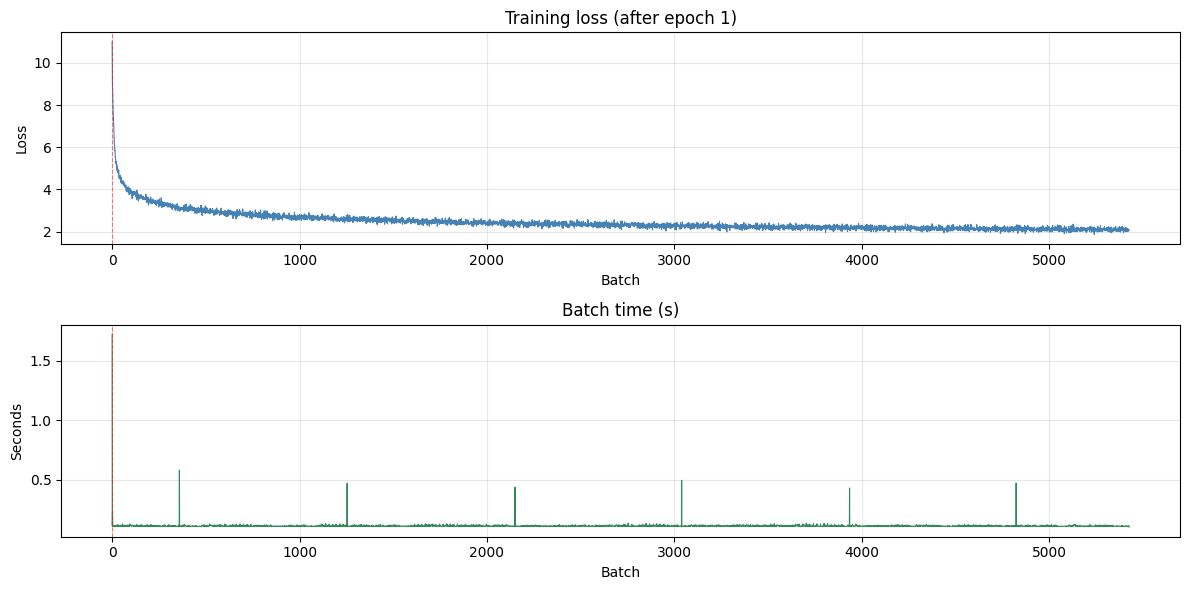

Epoch 2 | Batch 1000 | Loss: 2.0328 | Time: 0.107s
Epoch 2 | Batch 2000 | Loss: 1.9089 | Time: 0.106s
Epoch 2 | Batch 3000 | Loss: 2.0453 | Time: 0.106s
Epoch 2 | Batch 4000 | Loss: 1.9106 | Time: 0.109s
Epoch 2 | Batch 5000 | Loss: 1.8453 | Time: 0.114s

Epoch 2/5 | Avg Loss: 1.9504 | Time: 47m 37.8s
Generated: Once Upon timzy-Her friend comes to see her favorite place, Maria laughing. It is a park with a cool, fluffy and they laugh and they spent time playing.




















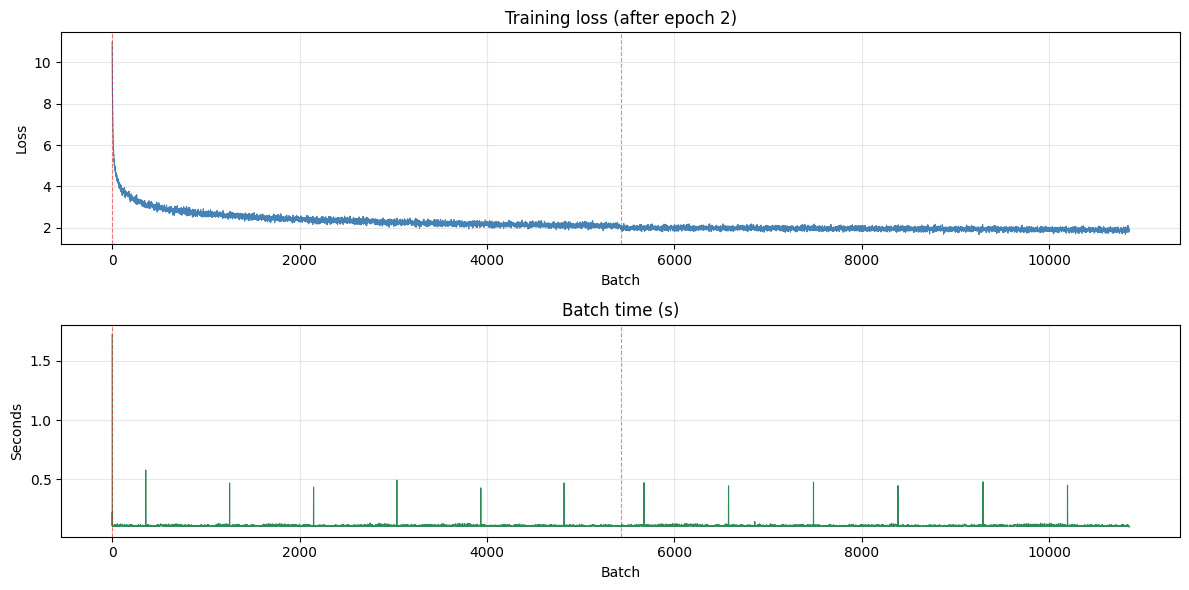

Epoch 3 | Batch 1000 | Loss: 1.8176 | Time: 0.106s
Epoch 3 | Batch 2000 | Loss: 1.7950 | Time: 0.107s
Epoch 3 | Batch 3000 | Loss: 1.8698 | Time: 0.112s
Epoch 3 | Batch 4000 | Loss: 1.7478 | Time: 0.111s
Epoch 3 | Batch 5000 | Loss: 1.7569 | Time: 0.112s

Epoch 3/5 | Avg Loss: 1.7884 | Time: 47m 37.6s
Generated: Once Upon timzoom, he happily playing a wonderful new skillful blurly royal Garden and changed colors blur with spots fu. Oliver joined the discuss followed his dad, talking (in friend that motivated ( Comet bell rang the non rotation only when the crows and


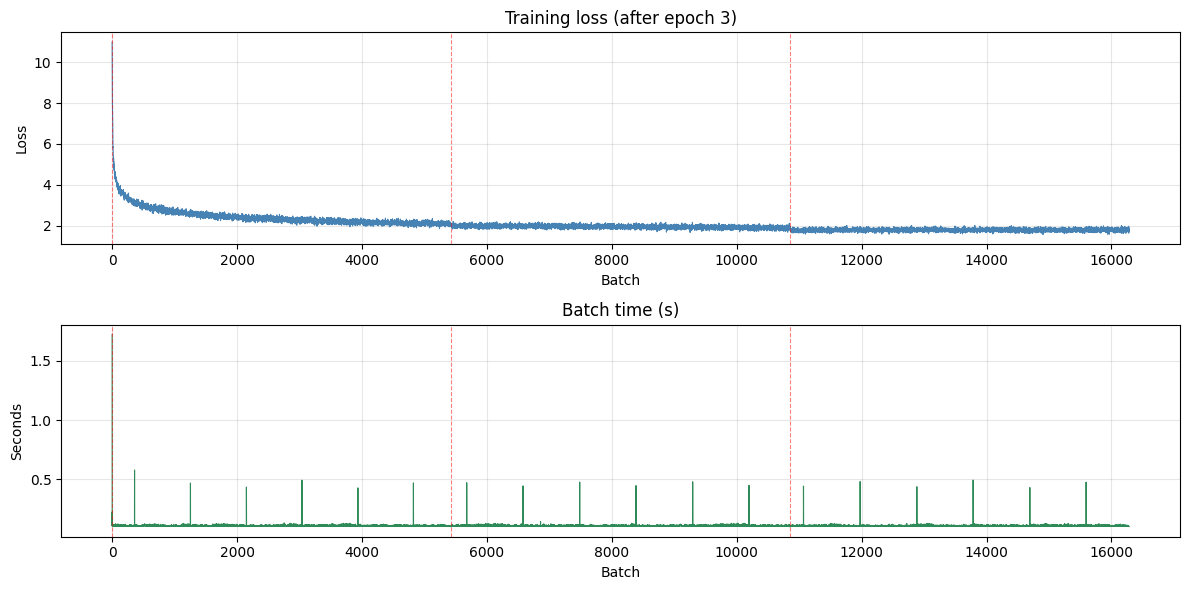

Epoch 4 | Batch 1000 | Loss: 1.6917 | Time: 0.105s
Epoch 4 | Batch 2000 | Loss: 1.5741 | Time: 0.106s
Epoch 4 | Batch 3000 | Loss: 1.6843 | Time: 0.107s
Epoch 4 | Batch 4000 | Loss: 1.5885 | Time: 0.104s
Epoch 4 | Batch 5000 | Loss: 1.6065 | Time: 0.105s

Epoch 4/5 | Avg Loss: 1.6764 | Time: 47m 36.5s
Generated: Once Upon timzanny was inside, she had seen.



Rain roof, her house? She was in front garden was a small house!
Pigail drove up the garden!



"What wouldrow is a garden? The


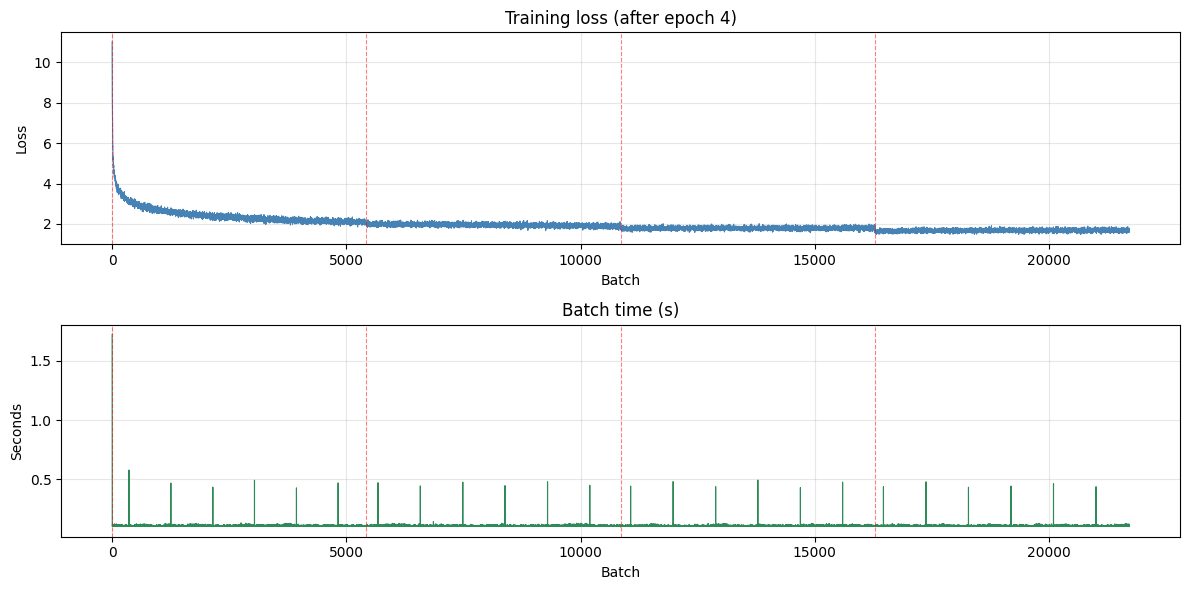

Epoch 5 | Batch 1000 | Loss: 1.5976 | Time: 0.116s
Epoch 5 | Batch 2000 | Loss: 1.6094 | Time: 0.111s


KeyboardInterrupt: 

In [46]:
import time
import matplotlib.pyplot as plt

prompt = "Once Upon timz"
num_epochs = 5
i = 1
training_start = time.time()

loss_history = []      # tracks loss per batch
time_history = []      # tracks time per batch
epoch_markers = []     # batch index where each epoch starts

for epoch in range(num_epochs):
    epoch_start = time.time()
    total_loss = 0
    num_batches = 0
    epoch_markers.append(len(loss_history))

    for x, y in train_loader:
        batch_start = time.time()
        x, y = x.to(device), y.to(device)
        logits = model(x)
        B, T, V = logits.shape
        logits = logits.contiguous().view(B*T, V)
        targets = y.contiguous().view(B*T)
        loss = criterion(logits, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_time = time.time() - batch_start

        loss_history.append(loss.item())
        time_history.append(batch_time)
        total_loss += loss.item()
        num_batches += 1
        i += 1

        if num_batches % 1000 == 0:
            print(f"Epoch {epoch+1} | Batch {num_batches} | Loss: {loss.item():.4f} | Time: {batch_time:.3f}s")

    avg_loss = total_loss / num_batches
    epoch_mins, epoch_secs = divmod(time.time() - epoch_start, 60)
    print(f"\nEpoch {epoch+1}/5 | Avg Loss: {avg_loss:.4f} | Time: {int(epoch_mins)}m {epoch_secs:.1f}s")
    generated_text = generate_inference(model.module, prompt, 50, tokenizer, device=device)
    print("Generated:", generated_text)
    print("="*50)

    # plot after each epoch so you can see progress live
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    ax1.plot(loss_history, color='steelblue', linewidth=0.8)
    for m in epoch_markers:
        ax1.axvline(m, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.set_title(f'Training loss (after epoch {epoch+1})')
    ax1.set_xlabel('Batch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

    ax2.plot(time_history, color='seagreen', linewidth=0.8)
    for m in epoch_markers:
        ax2.axvline(m, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax2.set_title('Batch time (s)')
    ax2.set_xlabel('Batch'); ax2.set_ylabel('Seconds'); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

total_time = time.time() - training_start
h, rem = divmod(total_time, 3600)
m, s = divmod(rem, 60)
print(f"\nTotal training time: {int(h)}h {int(m)}m {s:.1f}s")

In [ ]:
TEST_PROMPT = "Once there was a tall tree"
generated = generate_text(model, tokenizer, TEST_PROMPT, max_new_tokens=100, device=device)
print(f"📝 Generated text:")
print(f"   {generated}")
print(f"{'='*50}\n")

In [47]:
checkpoint = torch.load("/kaggle/input/datasets/redamalki/model-checkpoint-1/checkpoint.pth", map_location=device)

# model = MiniGPT(vocab_size, d_model, context_length, n_heads)
model.load_state_dict(checkpoint["model"])
model = model.to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
optimizer.load_state_dict(checkpoint["optimizer"])

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/redamalki/model-checkpoint-1/checkpoint.pth'

In [ ]:
import torch
x = torch.rand(3,4,5,2)

In [ ]:
print(x[ : , : , :4 , :].shape)